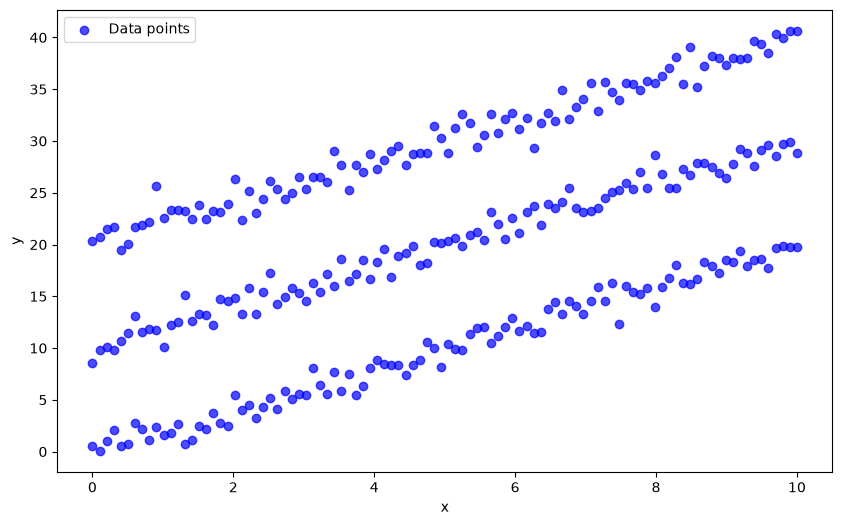

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Parameters for the three parallel lines
m = 2.0         # Common slope for all lines
c1 = 0.0        # Intercept for the first line
c2 = 10.0       # Intercept for the second line
c3 = 20.0       # Intercept for the third line
n_points = 100  # Number of points per line
noise_std = 1.0 # Standard deviation of the Gaussian noise

# Generate x-values uniformly for all lines
x_vals = np.linspace(0, 10, n_points)

# Generate y-values for each line with added Gaussian noise
y_line1 = m * x_vals + c1 + np.random.normal(0, noise_std, n_points)
y_line2 = m * x_vals + c2 + np.random.normal(0, noise_std, n_points)
y_line3 = m * x_vals + c3 + np.random.normal(0, noise_std, n_points)

# Combine the points from all three lines into one dataset
X = np.concatenate([x_vals, x_vals, x_vals]).reshape(-1, 1)
y = np.concatenate([y_line1, y_line2, y_line3])

# Optionally, shuffle the dataset so that the points from the three lines are intermingled
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Plot the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

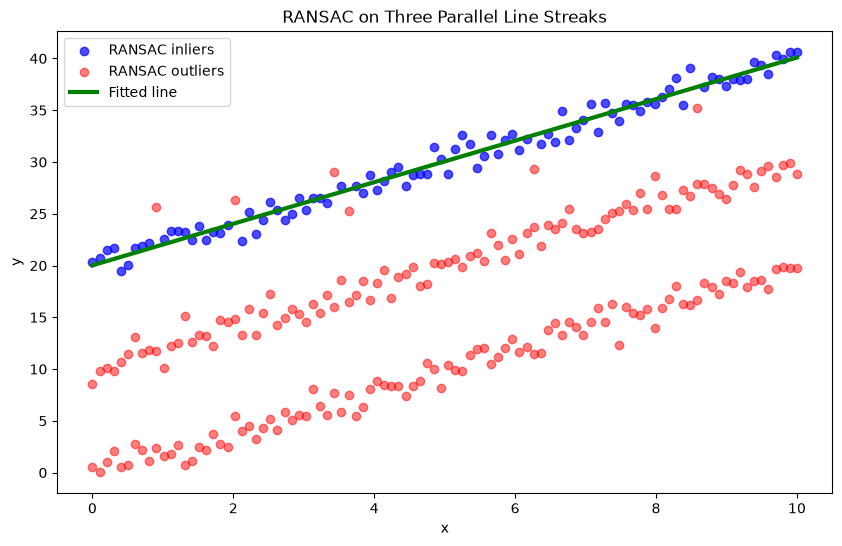

Number of inliers: 94
Number of outliers: 206


In [45]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    residual_threshold=2.0,
    random_state=42
)

ransac.fit(X, y)

inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask
line_X = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
line_y = ransac.predict(line_X)

plt.figure(figsize=(10, 6))
plt.scatter(
    X[inlier_mask],
    y[inlier_mask],
    color="blue",
    alpha=0.7,
    label="RANSAC inliers"
)
plt.scatter(
    X[outlier_mask],
    y[outlier_mask],
    color="red",
    alpha=0.5,
    label="RANSAC outliers"
)
plt.plot(
    line_X,
    line_y,
    color="green",
    linewidth=3,
    label="Fitted line"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("RANSAC on Three Parallel Line Streaks")
plt.legend()
plt.show()

print("Number of inliers:", inlier_mask.sum())
print("Number of outliers:", outlier_mask.sum())